# Preguntas que tenemos

- En el apartado 2.2 no hay que usar nuestra implementación?
- En el apartado 2.2 hay que comentar la precisión de los 24 modelos hechos con LOO? No se si tiene sentido porque casi todos tienen 100% de precisión, lógicamente.

# Construción da árbore de decisión

#### Imports

In [34]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

#### Implementación

In [3]:
from collections import Counter

class Node:
    # Inicializa os atributos do nodo
    def __init__(self, feature=None, threshold=None, value=None):
        self.feature = feature      # Variable escollida para a división
        self.threshold = threshold  # Valor limiar para a división
        self.left = None            # Referencia ao nodo esquerdo
        self.right = None           # Referencia ao nodo dereito
        self.value = value          # Valor da clase (só para nodos folla)

    # Comproba se o nodo é unha folla (non ten fillos)
    def is_leaf(self):
        return self.value is not None

class DecisionTree:
    """Clase para construír e utilizar o modelo de árbore de decisión."""

    # Inicializa os hiperparámetros da árbore
    def __init__(self, max_depth=None, max_leaf_nodes=None, min_samples_leaf=1):
        self.max_depth = max_depth                  # Profundidade máxima
        self.max_leaf_nodes = max_leaf_nodes        # Máximo número de follas
        self.min_samples_leaf = min_samples_leaf    # Minimo numero de elementos nun nodo para poder partilo
        self.root = None
        # Estas variables son únicamente para imprimir logo as características da árbore
        self._current_max_depth = 0
        self._leaves_count = 0
        self._total_nodes = 0
        self._leaf_labels = []      # Etiquetas dos nodos folla
        self._splits_by_level = {}  # Diccionario que garda o nivel {nivel: [features usadas]}

    # Comproba se se alcanzou a profundidade máxima ou se todas as etiquetas son iguais
    def is_finished(self, depth, num_labels):
        if (self.max_depth is not None and depth >= self.max_depth) or num_labels == 1:
            return True
        return False

    # Función auxiliar que devolve a etiqueta máis común nun vector de etiquetas
    @staticmethod
    def _most_common_label(y):
        counter = Counter(y)
        value = counter.most_common(1)[0][0]
        return value

    # Función recursiva que constrúe a árbore de decisión
    def _build_tree(self, X, y, depth=0):
        num_samples, num_features = X.shape
        num_labels = len(np.unique(y))

        self._total_nodes += 1

        # Evaluamos os casos de parada para determinar se o nodo é folla
        if self.is_finished(depth, num_labels) or (self.max_leaf_nodes is not None and self._leaves_count >= self.max_leaf_nodes):
            leaf_label = self._most_common_label(y)
            self._leaves_count += 1
            self._leaf_labels.append(leaf_label)    # Gardamos a etiqueta
            return Node(value=leaf_label)

        best_feat, best_thresh = self._best_split(X, y, num_features)

        # Se non podemos facer partición, o nodo é folla
        if best_feat is None:
            leaf_label = self._most_common_label(y)
            self._leaves_count += 1
            self._leaf_labels.append(leaf_label)    # Gardamos a etiqueta
            return Node(value=leaf_label)

        # Se o nodo é interno, gardamos a variable usada para poder logo imprimir os datos da árbore
        if depth not in self._splits_by_level:
            self._splits_by_level[depth] = []
        self._splits_by_level[depth].append(best_feat)

        if depth > self._current_max_depth:
            self._current_max_depth = depth

        current_node = Node(feature=best_feat, threshold=best_thresh)

        left_idxs, right_idxs = self._create_split(X[:, best_feat], best_thresh)
        current_node.left  = self._build_tree(X[left_idxs, :], y[left_idxs], depth + 1)
        current_node.right = self._build_tree(X[right_idxs, :], y[right_idxs], depth + 1)

        return current_node

    # Calcula a entropía dun conxunto de etiquetas
    def _entropy(self, y):
        # np.unique devolve os valores únicos e as súas frecuencias
        # Usamos '_' para ignorar o primeiro valor (os nomes das clases) xa que só queremos os conteos
        _, label_counts = np.unique(y, return_counts=True)
        ps = label_counts / len(y)
        return -np.sum([p * np.log2(p) for p in ps if p > 0])

    # Calcula a ganancia de información dunha división
    def _information_gain(self, y, left_idxs, right_idxs):
        parent_entropy = self._entropy(y)

        n = len(y)
        n_l, n_r = len(left_idxs), len(right_idxs)

        e_l, e_r = self._entropy(y[left_idxs]), self._entropy(y[right_idxs])
        children_entropy = (n_l / n) * e_l + (n_r / n) * e_r

        ig = parent_entropy - children_entropy
        return ig

    # Crea a división dos datos en función dunha característica e un umbral
    def _create_split(self, X_column, threshold):
        left_idxs = np.argwhere(X_column <= threshold).flatten()
        right_idxs = np.argwhere(X_column > threshold).flatten()
        return left_idxs, right_idxs

    # Busca a mellor división entre as características dispoñibles
    def _best_split(self, X, y, num_features):
        best_gain = -1
        split_idx, split_thresh = None, None

        for feat_idx in range(num_features):
            X_column = X[:, feat_idx]
            thresholds = np.unique(X_column)

            for thr in thresholds:
                left_idxs, right_idxs = self._create_split(X_column, thr)

                if len(left_idxs) < self.min_samples_leaf or len(right_idxs) < self.min_samples_leaf:
                    continue

                gain = self._information_gain(y, left_idxs, right_idxs)

                if gain > best_gain:
                    best_gain = gain
                    split_idx = feat_idx
                    split_thresh = thr

        return split_idx, split_thresh

    # Función recursiva para predecir a etiqueta dunha mostra seguindo a árbore
    def _traverse_tree(self, x, node):
        if node.is_leaf():
            return node.value

        if x[node.feature] <= node.threshold:
            return self._traverse_tree(x, node.left)
        return self._traverse_tree(x, node.right)

    # Constrúe a árbore de decisión a partir dos datos de adestramento
    def fit(self, X, y):
        X = np.array(X)
        y = np.array(y)

        # Construímos a árbore
        self._leaves_count = 0
        self._total_nodes = 0
        self._current_max_depth = 0
        self._leaf_labels = []
        self._splits_by_level = {}
        self.root = self._build_tree(X, y)

    # Predice as etiquetas das mostras de entrada
    def predict(self, X):
        X = np.array(X)
        return np.array([self._traverse_tree(x, self.root) for x in X])

    # Imprime as características da árbore
    def to_string(self):
        print("--- Datos da árbore ---")
        print(f"Número total de nodos:               {self._total_nodes}")
        print(f"Número de follas:                    {self._leaves_count}")
        print(f"Número de nodos internos:            {self._total_nodes - self._leaves_count}")
        print(f"Profundidade acadada (comeza en 0):  {self._current_max_depth}")
        print(f"Variables empregadas nas particións por nivel:")
        for level, feats in sorted(self._splits_by_level.items()):
            print(f"\tNivel {level}: {feats}")
        print(f"Etiquetas dos nodos folla: {self._leaf_labels}")

#### Breve proba da implementación

Faremos un pequeno test da implementación co conxunto de tipo de lentes de contacto, que é moi pequeno, pero será suficiente para comprobar se a árbore funciona correctamente.

In [4]:
# Cargamos os datos e inspeccionámolos manualmente
df_train = pd.read_csv("lenses.csv")
df_train.head()

,Age,Prescription,Astigmatic,TearRate,Label
0,young,myope,no,reduced,no lenses
1,young,myope,no,normal,soft
2,young,myope,yes,reduced,no lenses
3,young,myope,yes,normal,hard
4,young,hypermetrope,no,reduced,no lenses


In [5]:
# Tamaño do dataset
print("Tamaño do dataset:", len(df_train))

Tamaño do dataset: 24


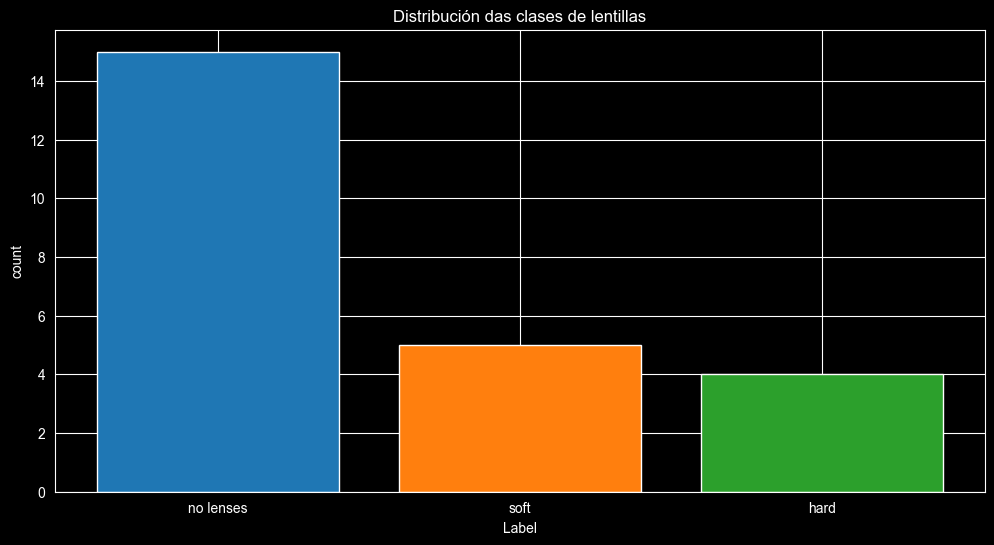

In [6]:
# Comprobamos a distribución das clases
class_counts = df_train['Label'].value_counts()

plt.figure(figsize=(12, 6))

# Creamos o gráfico de barras
# Dámoslle unhas cores semellantes ás que usaría seaborn por defecto
plt.bar(class_counts.index, class_counts.values, color=['#1f77b4', '#ff7f0e', '#2ca02c'])

# Engadimos as etiquetas aos eixos para que quede igual
plt.xlabel('Label')
plt.ylabel('count')
plt.title('Distribución das clases de lentillas')

plt.show()

In [7]:
# Para evitar o warning
pd.set_option('future.no_silent_downcasting', True)
def preparar_lentes(df):
    # Convertemos as variables categóricas a numéricas
    df.replace({
    "Age": {"young": 0, "pre-presbyopic": 1, "presbyopic": 2},
    "Prescription": {"myope": 0, "hypermetrope": 1},
    "Astigmatic": {"no": 0, "yes": 1},
    "TearRate": {"reduced": 0, "normal": 1},
    "Label": {"no lenses": 0, "soft": 1, "hard": 2}
    }, inplace=True)
    return df
df_train = preparar_lentes(df_train)

In [8]:
# Separamos as variables predictores da variable obxectivo
train_X = df_train.drop(columns=["Label"])
train_Y = df_train["Label"]
train_X.head()

,Age,Prescription,Astigmatic,TearRate
0,0,0,0,0
1,0,0,0,1
2,0,0,1,0
3,0,0,1,1
4,0,1,0,0


In [9]:
# Instanciamos a nosa árbore (sen límites para que medre ao máximo)
arbore_miope = DecisionTree()

# Adestramos a árbore cos datos
arbore_miope.fit(train_X, train_Y)

# Facemos as predicións sobre o propio conxunto de adestramento
predicions = arbore_miope.predict(train_X)

# Comparamos as predicións coas etiquetas reais para ver a precisión
def calcular_precision(predicions, etiquetas):
    return np.sum(predicions == etiquetas) / len(etiquetas)

def imprimir_resultados(predicions, etiquetas):
    arbore_miope.to_string()
    print("\n--- Resultados das predicións ---")
    print("Etiquetas reais: ", etiquetas)
    print("Predicións:      ", predicions)
    print(f"Precisión no adestramento: {calcular_precision(predicions, etiquetas) * 100:.2f}%")

imprimir_resultados(predicions, train_Y.values)

--- Datos da árbore ---
Número total de nodos:               13
Número de follas:                    7
Número de nodos internos:            6
Profundidade acadada (comeza en 0):  3
Variables empregadas nas particións por nivel:
	Nivel 0: [3]
	Nivel 1: [2]
	Nivel 2: [0, 1]
	Nivel 3: [1, 0]
Etiquetas dos nodos folla: [0, 1, 0, 1, 2, 2, 0]

--- Resultados das predicións ---
Etiquetas reais:  [0 1 0 2 0 1 0 2 0 1 0 2 0 1 0 0 0 0 0 2 0 1 0 0]
Predicións:       [0 1 0 2 0 1 0 2 0 1 0 2 0 1 0 0 0 0 0 2 0 1 0 0]
Precisión no adestramento: 100.00%


Moi probablemente cometeu sobreaprendizaxe, xa que non lle puxemos límites. Vexamos agora limitando o número mínimo de datos nun nodo para que se poda realizar a partición.

In [10]:
# Instanciamos a nosa árbore (sen límites para que medre ao máximo)
arbore_miope = DecisionTree(max_depth=10, max_leaf_nodes=10, min_samples_leaf=2)

# Adestramos a árbore cos datos
arbore_miope.fit(train_X, train_Y)

# Facemos as predicións sobre o propio conxunto de adestramento
predicions = arbore_miope.predict(train_X)

# Comparamos as predicións coas etiquetas reais para ver a precisión
imprimir_resultados(predicions, train_Y.values)

--- Datos da árbore ---
Número total de nodos:               9
Número de follas:                    5
Número de nodos internos:            4
Profundidade acadada (comeza en 0):  2
Variables empregadas nas particións por nivel:
	Nivel 0: [3]
	Nivel 1: [2]
	Nivel 2: [0, 1]
Etiquetas dos nodos folla: [0, 1, 0, 2, 0]

--- Resultados das predicións ---
Etiquetas reais:  [0 1 0 2 0 1 0 2 0 1 0 2 0 1 0 0 0 0 0 2 0 1 0 0]
Predicións:       [0 1 0 2 0 1 0 0 0 1 0 2 0 1 0 0 0 0 0 2 0 0 0 0]
Precisión no adestramento: 91.67%


En efecto, agora a árbore xa non ten unha precisión do 100%, xa que o número de particións se reduciu ao non permitir a creación de nodos cun só dato (os outros dous hiperparámetros non influíron neste caso).

Procederemos logo a adestrar a unha árbore sobre conxunto de datos grande.

# Adestramento e validación da árbore

Dado o pequeno tamano do conxunto de datos, empregaremos unha validación de tipo Leave One Out. Esto é, validación cruzada excluíndo un só dato de cada vez.

In [11]:
from sklearn.model_selection import LeaveOneOut

df = pd.read_csv("lenses.csv")

df = preparar_lentes(df)

X = df.drop(columns=["Label"])
y = df["Label"]

loo = LeaveOneOut()
loo.get_n_splits(X)

# Variables para levar a conta dos acertos
acertos = 0
total = len(X)

# Convertimos os DataFrames a arrays de numpy para facilitar a indexación
X_np = X.values
y_np = y.values

modelos_loo = []

# A función split devólvenos os índices de adestramento (23) e test (1) en cada paso
for i, (train_index, test_index) in enumerate(loo.split(X_np)):
    # Separamos os datos para esta iteración
    X_train, X_test = X_np[train_index], X_np[test_index]
    y_train, y_test = y_np[train_index], y_np[test_index]

    # Instanciamos un novo modelo limpo e adestrámolo
    modelo_loo = DecisionTree()
    modelo_loo.fit(X_train, y_train)
    modelos_loo.append(modelo_loo)

    # Facemos a predición para o único elemento de test
    predicion = modelo_loo.predict(X_test)

    # Comprobamos se a nosa predición coincide coa etiqueta real
    if predicion[0] == y_test[0]:
        acertos += 1

# Calculamos e amosamos a precisión final
precision_loo = acertos / total
print(f"Acertos: {acertos} de {total}")
print(f"Precisión con Leave-One-Out: {precision_loo * 100:.2f}%")

Acertos: 20 de 24
Precisión con Leave-One-Out: 83.33%


#### Interpretación das árbores

Vexamos cal é a árbore con máis precisión das 24.

In [12]:
for modelo in modelos_loo:
    predicions = modelo.predict(X)
    precision = calcular_precision(predicions, y.values)
    print(precision)

1.0
1.0
1.0
1.0
1.0
1.0
1.0
0.9583333333333334
1.0
1.0
1.0
1.0
1.0
1.0
1.0
0.9583333333333334
1.0
0.9583333333333334
1.0
1.0
1.0
0.9583333333333334
1.0
1.0


# Comparación cun modelo de *caixa negra*

Carguemos agora outros datos e comparemos a árbore cun MLP. Empregaremos o dataset [Abalone](https://archive.ics.uci.edu/dataset/1/abalone), o cal ten como etiquetas o número de aneis das setas. Vexamos o dataset.

In [13]:
df_abalone = pd.read_csv("abalone.csv")
display(df_abalone.head())

etiquetas = 'Rings'

,Sex,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight,Rings
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7


In [14]:
# Convertemos a variable categórica Sex en entera
df_abalone.replace({"Sex": {"M": 0, "F": 1, "I": 2}}, inplace=True)
df_abalone.head()

# A variable obxetivo ten demasiadas clases (29), e o problema é que algunhas delas teñen moi poucos elementos
# Por exemplo, a clase 29 ten só 1 elemento. Por iso, as imos agrupar.
# As agruparemos en intervalos desiguais para obter clases con número de elementos non tan desequilibrado
etiquetas2 = 'Clases'
df_clases = df_abalone.copy()

bins   = [0, 7, 9, 10, 11, 13, 30]
labels = ['1-7', '8-9', '10', '11', '12-13', '14+']

df_clases[etiquetas2] = pd.cut(df_abalone[etiquetas].astype(int), bins=bins, labels=labels)
df_clases = df_clases.dropna(subset=[etiquetas2])
df_clases = df_clases.drop(columns=[etiquetas])

print(f"--- Distribución das 6 clases ---")
print(df_clases[etiquetas2].value_counts().sort_index())
display(df_clases.head())

--- Distribución das 6 clases ---
Clases
1-7       839
8-9      1257
10        634
11        487
12-13     470
14+       490
Name: count, dtype: int64


,Sex,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight,Clases
0,0,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,14+
1,0,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,1-7
2,1,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,8-9
3,0,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10
4,2,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,1-7


In [15]:
# Separamos as etiquetas
X = df_clases.drop(columns=[etiquetas2])
y = df_clases[etiquetas2]

# Obtemos os conxuntos de train (85%) e test (15%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=42, stratify=y)
print("--- Conxuntos de adestramento e proba ---")
print(f"Adestramento:\t{X_train.shape[0]} filas.")
print(f"Test:\t\t\t{X_test.shape[0]} filas.")

# Normalizamos, xa que o MLP o necesita. Para a árbore no inflúe
scaler = StandardScaler()
X_train_norm = scaler.fit_transform(X_train)
X_test_norm = scaler.transform(X_test)

--- Conxuntos de adestramento e proba ---
Adestramento:	3550 filas.
Test:			627 filas.


In [16]:
arbores_resultados = []

print("| max_d\t| min_s\t| max_n\t| nodos\t| folls\t| intrn\t| prcsn\t|")
for max_depth in range(8, 10):
    for min_samples_leaf in range(3, 5):
        for max_leaf_nodes in range(30, 50, 10):
            dt = DecisionTree(max_depth=max_depth, min_samples_leaf=min_samples_leaf, max_leaf_nodes=max_leaf_nodes)
            dt.fit(X_test_norm, y_test)
            predicions = dt.predict(X_test_norm)
            precision = calcular_precision(predicions, y_test)
            arbores_resultados.append({
                'depth': max_depth,
                'min_s': min_samples_leaf,
                'max_n': max_leaf_nodes,
                'nodos': dt._total_nodes,
                'folls': dt._leaves_count,
                'intrn': dt._total_nodes - dt._leaves_count,
                'prcsn': precision,
                'etqts': dt._leaf_labels,
                'vrbls': dt._splits_by_level
            })
            print(f"| {max_depth}\t| {min_samples_leaf}\t| {max_leaf_nodes}\t| {dt._total_nodes}\t| {dt._leaves_count}\t| {dt._total_nodes - dt._leaves_count}\t| {precision:.3f}\t|")

| max_d	| min_s	| max_n	| nodos	| folls	| intrn	| prcsn	|
| 8	| 3	| 30	| 71	| 36	| 35	| 0.530	|
| 8	| 3	| 40	| 87	| 44	| 43	| 0.555	|
| 8	| 4	| 30	| 69	| 35	| 34	| 0.541	|
| 8	| 4	| 40	| 85	| 43	| 42	| 0.542	|
| 9	| 3	| 30	| 73	| 37	| 36	| 0.530	|
| 9	| 3	| 40	| 91	| 46	| 45	| 0.558	|
| 9	| 4	| 30	| 73	| 37	| 36	| 0.544	|
| 9	| 4	| 40	| 89	| 45	| 44	| 0.545	|


In [36]:
configuraciones = [(5,), (10,), (20,), (10, 5), (10, 10), (20, 10), (10, 5, 5), (20, 10, 5)]
taxas_aprendizaxe = [0.001, 0.005, 0.01]

mlp_resultados = []

print(f"| configuracion\t| taxa\t| precision\t|")
for configuracion in configuraciones:
    for taxa in taxas_aprendizaxe:
        mlp = MLPClassifier(
            hidden_layer_sizes=configuracion,
            learning_rate_init=taxa,
            max_iter=10000,
            random_state=42
        )
        mlp.fit(X_train_norm, y_train)
        precision = accuracy_score(y_test, mlp.predict(X_test_norm))
        mlp_resultados.append({'confg': configuracion, 'prcsn': precision})
        print(f"| {configuracion}\t| {taxa}\t| {precision:.3f}\t|")


| configuracion	| taxa	| precision	|
| (5,)	| 0.001	| 0.483	|
| (5,)	| 0.005	| 0.496	|
| (5,)	| 0.01	| 0.491	|
| (10,)	| 0.001	| 0.507	|
| (10,)	| 0.005	| 0.509	|
| (10,)	| 0.01	| 0.520	|
| (20,)	| 0.001	| 0.501	|
| (20,)	| 0.005	| 0.515	|
| (20,)	| 0.01	| 0.499	|
| (10, 5)	| 0.001	| 0.501	|
| (10, 5)	| 0.005	| 0.499	|
| (10, 5)	| 0.01	| 0.488	|
| (10, 10)	| 0.001	| 0.498	|
| (10, 10)	| 0.005	| 0.502	|
| (10, 10)	| 0.01	| 0.504	|
| (20, 10)	| 0.001	| 0.506	|
| (20, 10)	| 0.005	| 0.498	|
| (20, 10)	| 0.01	| 0.509	|
| (10, 5, 5)	| 0.001	| 0.493	|
| (10, 5, 5)	| 0.005	| 0.488	|
| (10, 5, 5)	| 0.01	| 0.498	|
| (20, 10, 5)	| 0.001	| 0.520	|
| (20, 10, 5)	| 0.005	| 0.514	|
| (20, 10, 5)	| 0.01	| 0.498	|



Gráfica gardada en 'abalone_dt_vs_mlp.png'


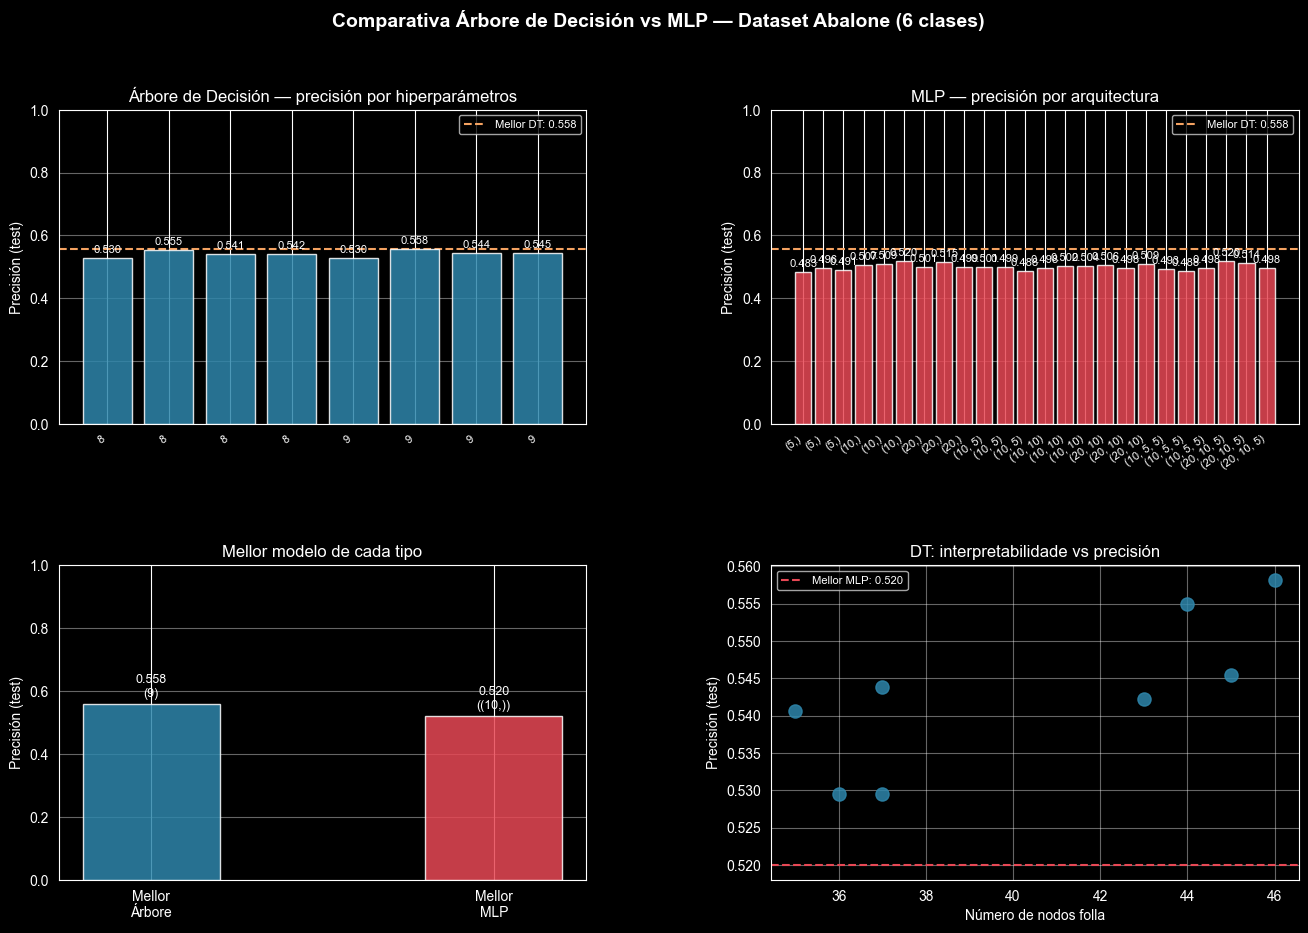

In [38]:
COLOR_DT  = '#2E86AB'   # azul
COLOR_MLP = '#E84855'   # vermello
COLOR_REF = '#F4A261'   # laranxa (liña de referencia mellor árbore)

dt_labels  = [r['depth'] for r in arbores_resultados]
dt_accs    = [r['prcsn']   for r in arbores_resultados]
dt_leaves  = [r['folls'] for r in arbores_resultados]

mlp_labels = [r['confg'] for r in mlp_resultados]
mlp_accs   = [r['prcsn']   for r in mlp_resultados]

best_dt_acc = max(dt_accs)
best_dt_idx = dt_accs.index(best_dt_acc)

fig = plt.figure(figsize=(16, 10))
fig.suptitle('Comparativa Árbore de Decisión vs MLP — Dataset Abalone (6 clases)',
             fontsize=14, fontweight='bold', y=0.98)

gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.35)

# --- Panel 1: Precisión DT por configuración ---
ax1 = fig.add_subplot(gs[0, 0])
bars = ax1.bar(range(len(dt_labels)), dt_accs, color=COLOR_DT, alpha=0.85, zorder=3)
ax1.axhline(best_dt_acc, color=COLOR_REF, linestyle='--', linewidth=1.5,
            label=f'Mellor DT: {best_dt_acc:.3f}')
ax1.set_xticks(range(len(dt_labels)))
ax1.set_xticklabels(dt_labels, rotation=35, ha='right', fontsize=8)
ax1.set_ylabel('Precisión (test)')
ax1.set_title('Árbore de Decisión — precisión por hiperparámetros')
ax1.set_ylim(0, 1)
ax1.yaxis.grid(True, alpha=0.4); ax1.set_axisbelow(True)
for bar, acc in zip(bars, dt_accs):
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
             f'{acc:.3f}', ha='center', va='bottom', fontsize=8)
ax1.legend(fontsize=8)

# --- Panel 2: Precisión MLP por arquitectura ---
ax2 = fig.add_subplot(gs[0, 1])
bars2 = ax2.bar(range(len(mlp_labels)), mlp_accs, color=COLOR_MLP, alpha=0.85, zorder=3)
ax2.axhline(best_dt_acc, color=COLOR_REF, linestyle='--', linewidth=1.5,
            label=f'Mellor DT: {best_dt_acc:.3f}')
ax2.set_xticks(range(len(mlp_labels)))
ax2.set_xticklabels(mlp_labels, rotation=35, ha='right', fontsize=8)
ax2.set_ylabel('Precisión (test)')
ax2.set_title('MLP — precisión por arquitectura')
ax2.set_ylim(0, 1)
ax2.yaxis.grid(True, alpha=0.4); ax2.set_axisbelow(True)
for bar, acc in zip(bars2, mlp_accs):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
             f'{acc:.3f}', ha='center', va='bottom', fontsize=8)
ax2.legend(fontsize=8)

# --- Panel 3: Comparación directa DT vs MLP (mellores de cada grupo) ---
ax3 = fig.add_subplot(gs[1, 0])
best_mlp_acc = max(mlp_accs)
best_mlp_lbl = mlp_labels[mlp_accs.index(best_mlp_acc)]
best_dt_lbl  = dt_labels[best_dt_idx]

categories = ['Mellor\nÁrbore', 'Mellor\nMLP']
values     = [best_dt_acc, best_mlp_acc]
colors     = [COLOR_DT, COLOR_MLP]
brs = ax3.bar(categories, values, color=colors, alpha=0.85, width=0.4, zorder=3)
ax3.set_ylabel('Precisión (test)')
ax3.set_title('Mellor modelo de cada tipo')
ax3.set_ylim(0, 1)
ax3.yaxis.grid(True, alpha=0.4); ax3.set_axisbelow(True)
for bar, acc, lbl in zip(brs, values, [best_dt_lbl, best_mlp_lbl]):
    ax3.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.015,
             f'{acc:.3f}\n({lbl})', ha='center', va='bottom', fontsize=9)

# --- Panel 4: Relación nº follas vs precisión nos DTs ---
ax4 = fig.add_subplot(gs[1, 1])
sc = ax4.scatter(dt_leaves, dt_accs, c=COLOR_DT, s=90, zorder=3, alpha=0.85)
ax4.axhline(best_mlp_acc, color=COLOR_MLP, linestyle='--', linewidth=1.5,
            label=f'Mellor MLP: {best_mlp_acc:.3f}')
for i, r in enumerate(arbores_resultados):
    ax4.annotate(r['depth'], (r['prcsn'], r['folls']),
                 textcoords='offset points', xytext=(6, 3), fontsize=7)
ax4.set_xlabel('Número de nodos folla')
ax4.set_ylabel('Precisión (test)')
ax4.set_title('DT: interpretabilidade vs precisión')
ax4.yaxis.grid(True, alpha=0.4); ax4.xaxis.grid(True, alpha=0.4)
ax4.set_axisbelow(True)
ax4.legend(fontsize=8)

plt.savefig('abalone_dt_vs_mlp.png', dpi=150, bbox_inches='tight')
print("\nGráfica gardada en 'abalone_dt_vs_mlp.png'")
plt.show()

